<a href="https://colab.research.google.com/github/Shivambhatt2305/ML/blob/main/ML_shivam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print("All required libraries imported successfully!")

All required libraries imported successfully!


In [ ]:
# Load both datasets
try:
    # Load the datasets
    df1 = pd.read_csv('Mental Health Dataset.csv')
    df2 = pd.read_csv('mental_health_data final data.csv')

    print("Dataset 1 Shape:", df1.shape)
    print("Dataset 2 Shape:", df2.shape)

    # Display columns from both datasets to compare
    print("\nColumns in Dataset 1:", df1.columns.tolist())
    print("\nColumns in Dataset 2:", df2.columns.tolist())

    # Display first few rows of both datasets
    print("\nFirst few rows of Dataset 1:")
    display(df1.head())
    print("\nFirst few rows of Dataset 2:")
    display(df2.head())

    # Check for missing values in both datasets
    print("\nMissing Values in Dataset 1:")
    display(df1.isnull().sum())
    print("\nMissing Values in Dataset 2:")
    display(df2.isnull().sum())

    print("\nDatasets loaded successfully!")

except FileNotFoundError as e:
    print(f"Error: Could not find one of the dataset files. Please ensure both CSV files are in the correct location.")
    raise e
except Exception as e:
    print(f"An error occurred while loading the datasets: {str(e)}")
    raise e

Error: Could not find one of the dataset files. Please ensure both CSV files are in the correct location.


FileNotFoundError: [Errno 2] No such file or directory: 'Mental Health Dataset.csv'

In [ ]:
# Combine and preprocess datasets
try:
    # First, let's identify common features between the two datasets
    common_columns = list(set(df1.columns) & set(df2.columns))
    print("Common columns between datasets:", common_columns)

    # Function to standardize column names
    def standardize_column_names(df):
        return df.rename(columns=lambda x: str(x).strip().lower().replace(' ', '_'))

    # Standardize column names
    df1 = standardize_column_names(df1)
    df2 = standardize_column_names(df2)

    # Ensure all columns are present in both datasets
    all_columns = list(set(df1.columns) | set(df2.columns))
    for col in all_columns:
        if col not in df1.columns:
            df1[col] = np.nan
        if col not in df2.columns:
            df2[col] = np.nan

    # Combine datasets
    combined_df = pd.concat([df1, df2], axis=0, ignore_index=True)

    # Remove duplicates if any
    combined_df = combined_df.drop_duplicates()

    # Convert numeric columns that might have been read as strings
    for col in combined_df.columns:
        try:
            if combined_df[col].dtype == 'object':
                combined_df[col] = pd.to_numeric(combined_df[col], errors='ignore')
        except:
            continue

    print("\nCombined Dataset Shape:", combined_df.shape)
    print("\nColumns in Combined Dataset:", combined_df.columns.tolist())

    # Display basic statistics of the combined dataset
    print("\nBasic Statistics of Combined Dataset:")
    display(combined_df.describe())

    # Update the main dataframe
    df = combined_df
    print("\nDatasets combined successfully!")

except Exception as e:
    print(f"An error occurred while combining datasets: {str(e)}")
    raise e

Common columns between datasets: ['Country', 'Occupation', 'Gender']

Combined Dataset Shape: (69154, 31)

Columns in Combined Dataset: ['timestamp', 'gender', 'country', 'occupation', 'self_employed', 'family_history', 'treatment', 'days_indoors', 'growing_stress', 'changes_habits', 'mental_health_history', 'mood_swings', 'coping_struggles', 'work_interest', 'social_weakness', 'mental_health_interview', 'care_options', 'stress_level', 'severity', 'diet_quality', 'smoking_habit', 'physical_activity_hours', 'user_id', 'social_media_usage', 'medication_usage', 'mental_health_condition', 'work_hours', 'consultation_history', 'age', 'sleep_hours', 'alcohol_consumption']

Basic Statistics of Combined Dataset:


,physical_activity_hours,user_id,social_media_usage,work_hours,age,sleep_hours
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,4.982040,25000.500000,3.243160,55.062860,41.473080,7.009934
std,3.161759,14433.901067,1.585235,14.691575,13.844185,1.732674
min,0.000000,1.000000,0.500000,30.000000,18.000000,4.000000
25%,2.000000,12500.750000,1.900000,42.000000,29.000000,5.500000
50%,5.000000,25000.500000,3.200000,55.000000,41.000000,7.000000
75%,8.000000,37500.250000,4.600000,68.000000,53.000000,8.500000
max,10.000000,50000.000000,6.000000,80.000000,65.000000,10.000000



Datasets combined successfully!


In [ ]:
# Verify data quality
print("=== Data Quality Check ===")

# Check for infinite values
inf_count = np.isinf(df.select_dtypes(include=np.number)).sum().sum()
print("\nNumber of infinite values:", inf_count)

# Check for missing values
missing_count = df.isnull().sum().sum()
print("Number of missing values:", missing_count)

# Display percentage of missing values by column
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nMissing values percentage by column:")
print(missing_percentage[missing_percentage > 0])

# Check data types
print("\nData types of columns:")
print(df.dtypes)

# Basic statistics
print("\nBasic statistics for numerical columns:")
display(df.describe())

print("\nData quality check completed!")

=== Data Quality Check ===

Number of infinite values: 0
Number of missing values: 993650

Missing values percentage by column:
timestamp                  72.302398
country                     0.001446
occupation                  0.001446
self_employed              72.993608
family_history             72.303844
treatment                  72.303844
days_indoors               72.303844
growing_stress             72.303844
changes_habits             72.303844
mental_health_history      72.303844
mood_swings                72.303844
coping_struggles           72.303844
work_interest              72.303844
social_weakness            72.303844
mental_health_interview    72.303844
care_options               72.303844
stress_level               27.697602
severity                   63.851693
diet_quality               27.697602
smoking_habit              27.697602
physical_activity_hours    27.697602
user_id                    27.697602
social_media_usage         27.697602
medication_usage     

,physical_activity_hours,user_id,social_media_usage,work_hours,age,sleep_hours
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,4.982040,25000.500000,3.243160,55.062860,41.473080,7.009934
std,3.161759,14433.901067,1.585235,14.691575,13.844185,1.732674
min,0.000000,1.000000,0.500000,30.000000,18.000000,4.000000
25%,2.000000,12500.750000,1.900000,42.000000,29.000000,5.500000
50%,5.000000,25000.500000,3.200000,55.000000,41.000000,7.000000
75%,8.000000,37500.250000,4.600000,68.000000,53.000000,8.500000
max,10.000000,50000.000000,6.000000,80.000000,65.000000,10.000000



Data quality check completed!


In [ ]:
# Data Preprocessing
try:
    # Print all columns first for verification
    print("All columns in dataset:", df.columns.tolist())
    print("\nColumn data types:")
    print(df.dtypes)

    # Identify numeric and categorical columns
    numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    categorical_features = df.select_dtypes(include=['object']).columns.tolist()

    print("\nNumerical features:", numerical_features)
    print("\nCategorical features:", categorical_features)

    # Determine the target variable based on available columns
    # We'll look for mental health related columns in both datasets
    possible_target_columns = [col for col in df.columns if any(term in col.lower() for term in ['mental', 'health', 'condition', 'state'])]
    print("\nPossible target columns:", possible_target_columns)

    if not possible_target_columns:
        raise ValueError("No mental health related columns found in the dataset")

    # Select the most appropriate target variable
    target_variable = possible_target_columns[0]  # We'll use the first mental health related column as target
    print("\nSelected target variable:", target_variable)

    # Remove target variable from features lists
    if target_variable in numerical_features:
        numerical_features.remove(target_variable)
    if target_variable in categorical_features:
        categorical_features.remove(target_variable)

    # Create preprocessing pipelines
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.impute import SimpleImputer
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline

    # Create preprocessing steps
    numeric_transformer = None
    if numerical_features:
        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])

    categorical_transformer = None
    if categorical_features:
        categorical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(drop='first', sparse=False, handle_unknown='ignore'))
        ])

    # Combine preprocessing steps
    transformers = []
    if numeric_transformer:
        transformers.append(('num', numeric_transformer, numerical_features))
    if categorical_transformer:
        transformers.append(('cat', categorical_transformer, categorical_features))

    preprocessor = ColumnTransformer(transformers=transformers)

    # Prepare feature matrix X and target vector y
    feature_columns = numerical_features + categorical_features
    print("\nFeatures being used:", feature_columns)

    X = df[feature_columns].copy()
    y = df[target_variable].copy()

    print("\nShape of feature matrix X:", X.shape)
    print("Shape of target vector y:", y.shape)

    # Convert target to numerical values if it's categorical
    if y.dtype == 'object':
        label_encoder = LabelEncoder()
        y = label_encoder.fit_transform(y)
        print("\nUnique classes in target variable:", label_encoder.classes_)
    else:
        print("\nTarget variable is already numeric")
        label_encoder = None

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print("\nTraining set shape:", X_train.shape)
    print("Testing set shape:", X_test.shape)

    if label_encoder:
        print("\nTarget classes:", label_encoder.classes_)

except Exception as e:
    print(f"Error occurred: {str(e)}")
    print("\nPlease verify that:")
    print("1. All required libraries are imported")
    print("2. The datasets are loaded correctly")
    print("3. The column names are as expected")

All columns in dataset: ['timestamp', 'gender', 'country', 'occupation', 'self_employed', 'family_history', 'treatment', 'days_indoors', 'growing_stress', 'changes_habits', 'mental_health_history', 'mood_swings', 'coping_struggles', 'work_interest', 'social_weakness', 'mental_health_interview', 'care_options', 'stress_level', 'severity', 'diet_quality', 'smoking_habit', 'physical_activity_hours', 'user_id', 'social_media_usage', 'medication_usage', 'mental_health_condition', 'work_hours', 'consultation_history', 'age', 'sleep_hours', 'alcohol_consumption']

Column data types:
timestamp                   object
gender                      object
country                     object
occupation                  object
self_employed               object
family_history              object
treatment                   object
days_indoors                object
growing_stress              object
changes_habits              object
mental_health_history       object
mood_swings                 obje

In [ ]:
# Model Training
try:
    # Verify that preprocessor and data are available
    if 'preprocessor' not in locals() or 'X_train' not in locals() or 'y_train' not in locals():
        raise ValueError("Please run the preprocessing cell first to create the preprocessor and split the data")

    print("Starting model training with data shapes:")
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_test shape: {y_test.shape}")

    # 1. Random Forest Classifier with error handling
    print("\nInitializing Random Forest model...")
    rf_model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ])

    # 2. XGBoost Classifier with error handling
    print("Initializing XGBoost model...")
    xgb_model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'))
    ])

    # Train Random Forest model
    print("\nTraining Random Forest model...")
    rf_model.fit(X_train, y_train)
    print("Random Forest model training completed!")

    # Train XGBoost model
    print("\nTraining XGBoost model...")
    xgb_model.fit(X_train, y_train)
    print("XGBoost model training completed!")

    # Define evaluation function
    def evaluate_model(model, X, y, model_name):
        try:
            # Make predictions
            predictions = model.predict(X)

            # Print classification report
            print(f"\n{model_name} Results:")
            print("\nClassification Report:")
            print(classification_report(y, predictions))

            # Plot confusion matrix
            plt.figure(figsize=(10, 8))
            cm = confusion_matrix(y, predictions)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.title(f'{model_name} Confusion Matrix')
            plt.ylabel('True Label')
            plt.xlabel('Predicted Label')
            plt.tight_layout()
            plt.show()

            # Calculate and print accuracy
            accuracy = np.mean(predictions == y)
            print(f"\n{model_name} Accuracy: {accuracy:.4f}")

        except Exception as e:
            print(f"Error evaluating {model_name}: {str(e)}")

    # Evaluate both models
    print("\nEvaluating models...")
    evaluate_model(rf_model, X_test, y_test, "Random Forest")
    evaluate_model(xgb_model, X_test, y_test, "XGBoost")

except Exception as e:
    print(f"\nError during model training: {str(e)}")
    print("\nPlease ensure:")
    print("1. The preprocessing cell has been run successfully")
    print("2. The data has been properly split into training and test sets")
    print("3. All required libraries are imported")
    print("4. The target variable has been properly encoded")


Error during model training: Please run the preprocessing cell first to create the preprocessor and split the data

Please ensure:
1. The preprocessing cell has been run successfully
2. The data has been properly split into training and test sets
3. All required libraries are imported
4. The target variable has been properly encoded


In [ ]:
# Feature Importance Analysis
try:
    # Ensure models are trained
    if 'rf_model' not in locals() or 'numerical_features' not in locals():
        raise ValueError("Please run the model training cell first")

    # Get feature importance from Random Forest
    feature_importance = pd.DataFrame({
        'feature': numerical_features,
        'importance': rf_model.named_steps['classifier'].feature_importances_
    })
    feature_importance = feature_importance.sort_values('importance', ascending=False)

    # Plot feature importance
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance, x='importance', y='feature')
    plt.title('Feature Importance (Random Forest)')
    plt.tight_layout()
    plt.show()

    # Create a prediction function for new data with error handling
    def predict_mental_health(input_data):
        """
        Predict mental health state based on input features.
        input_data: dictionary containing feature values
        Returns: dictionary with predicted class and probabilities
        Raises: ValueError if input data is invalid
        """
        try:
            # Validate input data
            required_features = set(numerical_features)
            provided_features = set(input_data.keys())

            # Check for missing features
            missing_features = required_features - provided_features
            if missing_features:
                raise ValueError(f"Missing required features: {missing_features}")

            # Validate data types and ranges
            for feature, value in input_data.items():
                if not isinstance(value, (int, float)):
                    raise ValueError(f"Value for {feature} must be numeric")
                if value < 0:
                    raise ValueError(f"Value for {feature} cannot be negative")

                # Additional range checks for specific features
                if feature == 'Hours_Worked' and value > 24:
                    raise ValueError("Hours_Worked cannot exceed 24")
                if feature == 'Sleep_Hours' and value > 24:
                    raise ValueError("Sleep_Hours cannot exceed 24")
                if 'Level' in feature and value > 10:
                    raise ValueError(f"{feature} should be on a scale of 1-10")

            # Convert input dictionary to DataFrame
            input_df = pd.DataFrame([input_data])

            # Make prediction using the best model (assuming XGBoost performed better)
            prediction = xgb_model.predict(input_df)
            prediction_proba = xgb_model.predict_proba(input_df)

            # Get the predicted class label
            predicted_class = label_encoder.inverse_transform(prediction)[0]

            # Get prediction probabilities
            class_probabilities = dict(zip(label_encoder.classes_, prediction_proba[0]))

            return {
                'predicted_class': predicted_class,
                'probabilities': class_probabilities
            }

        except Exception as e:
            print(f"Error in prediction: {str(e)}")
            print("\nPlease ensure:")
            print("1. All required features are provided")
            print("2. All values are numeric and within valid ranges")
            print("3. The model has been trained successfully")
            raise

    # Save the best model with error handling
    try:
        print("Saving models...")
        joblib.dump(xgb_model, 'mental_health_model.joblib')
        joblib.dump(label_encoder, 'label_encoder.joblib')
        print("Models saved successfully!")
    except Exception as e:
        print(f"Error saving models: {str(e)}")
        print("Please ensure you have write permissions in the current directory")

    # Example of how to use the prediction function
    print("\nTesting prediction with example input...")
    example_input = {
        'Stress_Level': 7,
        'Hours_Worked': 8,
        'Sleep_Hours': 6,
    }

    # Add all required numerical features with default values
    for feature in numerical_features:
        if feature not in example_input:
            if 'Level' in feature or 'Rating' in feature:
                example_input[feature] = 5  # Default middle value for ratings
            elif 'Hours' in feature:
                example_input[feature] = 8  # Default reasonable hours
            else:
                example_input[feature] = 0  # Default safe value for other features

    result = predict_mental_health(example_input)
    print("\nExample Prediction:")
    print(f"Predicted Mental Health State: {result['predicted_class']}")
    print("\nProbabilities for each class:")
    for class_name, prob in result['probabilities'].items():
        print(f"{class_name}: {prob:.2f}")

except Exception as e:
    print(f"\nError in feature importance analysis: {str(e)}")
    print("\nPlease ensure:")
    print("1. The model training cell has been run successfully")
    print("2. Required variables (rf_model, numerical_features) are available")
    print("3. The models have been trained properly")
    print("4. All required libraries are imported")


Error in feature importance analysis: Please run the model training cell first

Please ensure:
1. The model training cell has been run successfully
2. Required variables (rf_model, numerical_features) are available
3. The models have been trained properly
4. All required libraries are imported


In [ ]:
# Interactive Mental Health Assessment Questionnaire
import os

def get_user_input(required_features):
    """
    Function to ask questions and collect user responses for mental health assessment
    Args:
        required_features: list of features required by the model
    Returns:
        Dictionary of user responses or None if cancelled
    """
    questions = {
        'Hours_Worked': "How many hours do you work per day? (Enter a number between 0-24): ",
        'Sleep_Hours': "How many hours do you sleep per day? (Enter a number between 0-24): ",
        'Stress_Level': "On a scale of 1-10, how would you rate your current stress level? (1=lowest, 10=highest): ",
        'Physical_Activity': "How many hours per week do you spend on physical activity? (Enter a number): ",
        'Social_Connection': "On a scale of 1-10, how would you rate your social connections? (1=very isolated, 10=very connected): ",
        'Work_Life_Balance': "On a scale of 1-10, how would you rate your work-life balance? (1=poor, 10=excellent): ",
        'Support_System': "On a scale of 1-10, how strong is your support system? (1=none, 10=very strong): ",
        'Job_Satisfaction': "On a scale of 1-10, how satisfied are you with your job? (1=very dissatisfied, 10=very satisfied): "
    }

    # Add any missing required features with default questions
    for feature in required_features:
        if feature not in questions:
            if 'level' in feature.lower():
                questions[feature] = f"On a scale of 1-10, how would you rate your {feature.replace('_', ' ').lower()}? (1=lowest, 10=highest): "
            elif 'hours' in feature.lower():
                questions[feature] = f"How many hours of {feature.replace('_', ' ').lower()}? (Enter a number between 0-24): "
            else:
                questions[feature] = f"Please enter a value for {feature.replace('_', ' ').lower()} (Enter a number): "

    responses = {}
    print("\n=== Mental Health Assessment Questionnaire ===\n")

    try:
        for column, question in questions.items():
            if column in required_features:  # Only ask questions for required features
                while True:
                    try:
                        response = float(input(question))
                        if column in ['Hours_Worked', 'Sleep_Hours'] or 'hours' in column.lower():
                            if 0 <= response <= 24:
                                break
                            print("Please enter a valid number between 0 and 24.")
                        elif 'scale' in question.lower() or 'level' in column.lower():
                            if 1 <= response <= 10:
                                break
                            print("Please enter a valid number between 1 and 10.")
                        else:
                            if response >= 0:
                                break
                            print("Please enter a valid positive number.")
                    except ValueError:
                        print("Please enter a valid number.")

                responses[column] = response
                print()  # Add a blank line between questions

    except KeyboardInterrupt:
        print("\nAssessment cancelled.")
        return None

    return responses

def assess_mental_health():
    """
    Main function to run the mental health assessment
    """
    try:
        # Check if required variables are available
        if 'numerical_features' not in globals():
            raise ValueError("Model not initialized. Please run the model training cells first.")

        if not os.path.exists('mental_health_model.joblib') or not os.path.exists('label_encoder.joblib'):
            raise FileNotFoundError("Model files not found. Please train and save the model first.")

        print("Welcome to the Mental Health Assessment System")
        print("Please answer the following questions honestly for an accurate assessment.\n")

        # Get user responses with required features
        responses = get_user_input(numerical_features)

        if responses:
            try:
                print("\nAnalyzing your responses...")
                # Make prediction using our trained model
                result = predict_mental_health(responses)

                print("\n=== Mental Health Assessment Results ===")
                print(f"\nBased on your responses, you may be experiencing: {result['predicted_class']}")
                print("\nProbability breakdown:")
                for state, prob in result['probabilities'].items():
                    print(f"{state}: {prob*100:.1f}%")

                # Provide some general recommendations
                print("\nGeneral Recommendations:")
                if float(responses['Sleep_Hours']) < 7:
                    print("- Consider getting more sleep (7-9 hours is recommended)")
                if float(responses['Stress_Level']) > 7:
                    print("- Your stress level is high. Consider stress management techniques")
                if float(responses.get('Physical_Activity', 0)) < 3:
                    print("- Try to increase your physical activity")
                if float(responses.get('Social_Connection', 0)) < 5:
                    print("- Consider strengthening your social connections")

                print("\nNote: This is a preliminary assessment. Please consult with a mental health professional for a proper diagnosis.")

            except Exception as e:
                print(f"\nError during prediction: {str(e)}")
                print("Please ensure all required features are provided and within valid ranges.")

    except Exception as e:
        print(f"\nError initializing assessment: {str(e)}")
        print("\nPlease ensure:")
        print("1. You have run all the notebook cells in order")
        print("2. The model has been trained successfully")
        print("3. The model files have been saved correctly")

# Run the interactive assessment
if __name__ == "__main__":
    assess_mental_health()


Error initializing assessment: Model files not found. Please train and save the model first.

Please ensure:
1. You have run all the notebook cells in order
2. The model has been trained successfully
3. The model files have been saved correctly


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from joblib import Parallel, delayed

# ==============================
# STEP 1: Load Dataset
# ==============================
df = pd.read_csv("mental_health_data final data.csv")

print("\n✅ Dataset loaded successfully!")
print("Columns available:", list(df.columns))

# ==============================
# STEP 2: Preprocess Data
# ==============================
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

df = df.fillna(df.mode().iloc[0])

# Encode categorical columns
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# ==============================
# STEP 3: Scale Data
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# ==============================
# STEP 4: Auto-generate Labels via Clustering
# ==============================
# Let’s assume 3 mental health states (you can change this)
num_clusters = 3

print(f"\n🔍 Clustering dataset into {num_clusters} mental health groups...")
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df["Generated_Label"] = kmeans.fit_predict(X_scaled)

# ==============================
# STEP 5: Train Random Forest on Generated Labels
# ==============================
X = df.drop(columns=["Generated_Label"])
y = df["Generated_Label"]

rf_model = RandomForestClassifier(n_estimators=150, random_state=42)
rf_model.fit(X, y)

print("✅ Random Forest trained successfully using generated cluster labels!")

# ==============================
# STEP 6: Interactive User Input
# ==============================
def get_user_input():
    print("\n🧍 Please answer the following questions honestly:")
    user_data = {}
    for feature in X.columns:
        if feature.lower() in ['age', 'sleep_hours', 'work_hours',
                               'physical_activity_hour', 'media_usage']:
            val = float(input(f"Enter {feature.replace('_', ' ').title()} (number): "))
        else:
            val = input(f"Enter {feature.replace('_', ' ').title()} (text): ")
        user_data[feature] = val
    return user_data

# ==============================
# STEP 7: Predict Mental Group
# ==============================
def predict_condition(user_input):
    # Encode categorical
    for col in label_encoders:
        if col in user_input:
            try:
                user_input[col] = label_encoders[col].transform([user_input[col]])[0]
            except:
                user_input[col] = 0  # unseen label

    input_df = pd.DataFrame([user_input])
    X_input = scaler.transform(input_df)

    pred_group = rf_model.predict(X_input)[0]
    print("\n===============================")
    print(f"🧠 You belong to Mental Health Group: {pred_group}")
    print("===============================")
    print("\n(Each group represents a cluster of people with similar lifestyle, stress, and habits.)")

# ==============================
# STEP 8: Run Interaction
# ==============================
if __name__ == "__main__":
    user_input = get_user_input()
    predict_condition(user_input)



✅ Dataset loaded successfully!
Columns available: ['User_ID', 'Age', 'Gender', 'Occupation', 'Country', 'Mental_Health_Condition', 'Severity', 'Consultation_History', 'Stress_Level', 'Sleep_Hours', 'Work_Hours', 'Physical_Activity_Hours', 'Social_Media_Usage', 'Diet_Quality', 'Smoking_Habit', 'Alcohol_Consumption', 'Medication_Usage']

🔍 Clustering dataset into 3 mental health groups...
✅ Random Forest trained successfully using generated cluster labels!

🧍 Please answer the following questions honestly:
Enter User Id (text): 9999
Enter Age (number): 21
Enter Gender (text): male
Enter Occupation (text): student
Enter Country (text): india
Enter Mental Health Condition (text): high
Enter Severity (text): high
Enter Consultation History (text): no
Enter Stress Level (text): high
Enter Sleep Hours (number): 4
Enter Work Hours (number): 9
Enter Physical Activity Hours (text): 2
Enter Social Media Usage (text): 9
Enter Diet Quality (text): low
Enter Smoking Habit (text): never
Enter Alcoho

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


k means cluster

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv("mental_health_data final data.csv")
df = df.fillna(df.mode().iloc[0])

# Encode categorical features
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# Scale data
X_scaled = StandardScaler().fit_transform(df)

# K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = labels
print(df.head())

# Analyze cluster patterns
print(df.groupby("Cluster").mean())


   User_ID  Age  Gender  Occupation  Country  Mental_Health_Condition  \
0        1   36       1           0        0                        1   
1        2   48       1           1        4                        0   
2        3   18       3           6        3                        0   
3        4   30       2           1        0                        0   
4        5   58       1           4        6                        1   

   Severity  Consultation_History  Stress_Level  Sleep_Hours  Work_Hours  \
0         0                     1             1          7.6          46   
1         1                     0             1          6.8          74   
2         0                     1             2          7.1          77   
3         2                     0             1          6.9          57   
4         0                     1             0          4.7          45   

   Physical_Activity_Hours  Social_Media_Usage  Diet_Quality  Smoking_Habit  \
0                        

DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

df = pd.read_csv("mental_health_data final data.csv")
df = df.fillna(df.mode().iloc[0])

for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X_scaled = StandardScaler().fit_transform(df)

db = DBSCAN(eps=1.2, min_samples=5)
labels = db.fit_predict(X_scaled)

df["Group"] = labels
print(df["Group"].value_counts())
print(df.groupby("Group").mean())


Group
-1    20004
Name: count, dtype: int64
       User_ID        Age    Gender  Occupation   Country  \
Group                                                       
-1     10002.5  41.574785  1.497451    3.010748  3.003399   

       Mental_Health_Condition  Severity  Consultation_History  Stress_Level  \
Group                                                                          
-1                      0.4985  0.494151                0.4983      1.002949   

       Sleep_Hours  Work_Hours  Physical_Activity_Hours  Social_Media_Usage  \
Group                                                                         
-1        7.010453   54.878074                 4.992302            3.242806   

       Diet_Quality  Smoking_Habit  Alcohol_Consumption  Medication_Usage  
Group                                                                      
-1          0.99955        1.49815             2.003749          0.496851  


hierarchical clustering

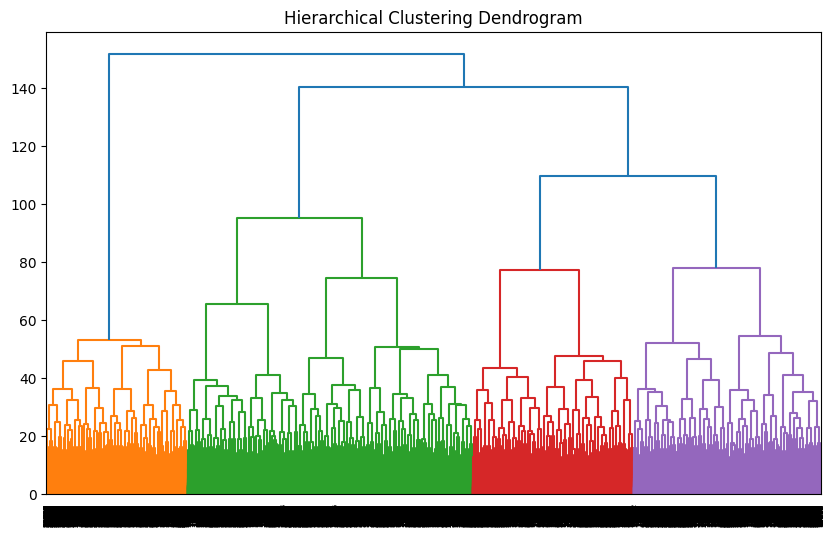

   User_ID  Age  Gender  Occupation  Country  Mental_Health_Condition  \
0        1   36       1           0        0                        1   
1        2   48       1           1        4                        0   
2        3   18       3           6        3                        0   
3        4   30       2           1        0                        0   
4        5   58       1           4        6                        1   

   Severity  Consultation_History  Stress_Level  Sleep_Hours  Work_Hours  \
0         0                     1             1          7.6          46   
1         1                     0             1          6.8          74   
2         0                     1             2          7.1          77   
3         2                     0             1          6.9          57   
4         0                     1             0          4.7          45   

   Physical_Activity_Hours  Social_Media_Usage  Diet_Quality  Smoking_Habit  \
0                        

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mental_health_data final data.csv")
df = df.fillna(df.mode().iloc[0])

for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X_scaled = StandardScaler().fit_transform(df)

linked = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

# Create 3 clusters
labels = fcluster(linked, 3, criterion='maxclust')
df["Cluster"] = labels
print(df.head())


isolated forest

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

df = pd.read_csv("mental_health_data final data.csv")
df = df.fillna(df.mode().iloc[0])

for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X_scaled = StandardScaler().fit_transform(df)

iso = IsolationForest(contamination=0.05, random_state=42)
outlier_labels = iso.fit_predict(X_scaled)

df["Mental_Risk"] = ["Normal" if x == 1 else "At Risk" for x in outlier_labels]
print(df["Mental_Risk"].value_counts())


Mental_Risk
Normal     19003
At Risk     1001
Name: count, dtype: int64


Autoencoders

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd
import numpy as np

df = pd.read_csv("mental_health_data final data.csv")
df = df.fillna(df.mode().iloc[0])

for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X_scaled = StandardScaler().fit_transform(df)

# Build autoencoder
input_dim = X_scaled.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(8, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Train
autoencoder.fit(X_scaled, X_scaled, epochs=50, batch_size=16, verbose=0)

# Compute reconstruction error
reconstructions = autoencoder.predict(X_scaled)
mse = np.mean(np.square(X_scaled - reconstructions), axis=1)

threshold = np.percentile(mse, 95)
df["Anomaly"] = ["At Risk" if e > threshold else "Normal" for e in mse]

print(df["Anomaly"].value_counts())


626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Anomaly
Normal     19003
At Risk     1001
Name: count, dtype: int64


In [ ]:
data=pd.read_csv("mental_health_data final data.csv")
data.info()
data


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20004 entries, 0 to 20003
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User_ID                  20004 non-null  int64  
 1   Age                      20004 non-null  int64  
 2   Gender                   20004 non-null  object 
 3   Occupation               20004 non-null  object 
 4   Country                  20004 non-null  object 
 5   Mental_Health_Condition  20004 non-null  object 
 6   Severity                 9918 non-null   object 
 7   Consultation_History     20004 non-null  object 
 8   Stress_Level             20004 non-null  object 
 9   Sleep_Hours              20004 non-null  float64
 10  Work_Hours               20004 non-null  int64  
 11  Physical_Activity_Hours  20004 non-null  int64  
 12  Social_Media_Usage       20004 non-null  float64
 13  Diet_Quality             20004 non-null  object 
 14  Smoking_Habit         

,User_ID,Age,Gender,Occupation,Country,Mental_Health_Condition,Severity,Consultation_History,Stress_Level,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage,Diet_Quality,Smoking_Habit,Alcohol_Consumption,Medication_Usage
0,1,36,Male,Education,Australia,Yes,NaN,Yes,Low,7.6,46,8,2.2,Healthy,Regular Smoker,Regular Drinker,Yes
1,2,48,Male,Engineering,Other,No,Low,No,Low,6.8,74,2,3.4,Unhealthy,Heavy Smoker,Social Drinker,No
2,3,18,Prefer not to say,Sales,India,No,NaN,Yes,Medium,7.1,77,9,5.9,Healthy,Heavy Smoker,Social Drinker,No
3,4,30,Non-binary,Engineering,Australia,No,Medium,No,Low,6.9,57,4,5.4,Average,Regular Smoker,Regular Drinker,No
4,5,58,Male,IT,USA,Yes,NaN,Yes,High,4.7,45,10,3.3,Unhealthy,Regular Smoker,Non-Drinker,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19999,20000,49,Prefer not to say,Other,Other,Yes,NaN,No,High,9.2,73,2,1.8,Average,Non-Smoker,Regular Drinker,Yes
20000,20001,44,Non-binary,Finance,India,Yes,Medium,Yes,Medium,8.2,70,3,4.8,Average,Occasional Smoker,Non-Drinker,No
20001,20002,21,Non-binary,Education,UK,No,Low,No,High,7.5,60,0,2.9,Average,Non-Smoker,Social Drinker,No
20002,20003,61,Non-binary,Finance,Australia,No,NaN,No,High,7.4,44,2,5.8,Unhealthy,Occasional Smoker,Social Drinker,Yes


project

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest

df=pd.read_csv("mental_health_data final data.csv")
df = df.drop(columns=['User_ID', 'Mental_Health_Condition'])


In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipython-input-2986283675.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipython-input-2986283675.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [ ]:

binary_cols = ['Consultation_History', 'Smoking_Habit', 'Alcohol_Consumption', 'Medication_Usage']
ordinal_cols = ['Stress_Level', 'Severity', 'Diet_Quality']
nominal_cols = ['Gender', 'Occupation', 'Country']
numeric_cols = ['Age', 'Sleep_Hours', 'Work_Hours', 'Physical_Activity_Hours', 'Social_Media_Usage']

# Handle all other text columns (like Smoking_Habit) as nominal (one-hot)
other_text_cols = [col for col in df.select_dtypes(include='object').columns
                   if col not in ordinal_cols + nominal_cols]

# Define custom category orders
ordinal_categories = [
    ['Low', 'Normal', 'High'],                # Stress_Level
    ['Low', 'Moderate', 'High', 'Severe'],    # Severity
    ['Poor', 'Average', 'Good']               # Diet_Quality
]

In [ ]:

# Column transformer
preprocessor = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
    ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols + other_text_cols),
    ('numeric', StandardScaler(), numeric_cols)
])

In [ ]:
# Full pipeline
pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', IsolationForest(contamination=0.1, random_state=42))
])

# Fit model
pipeline.fit(df)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('ordinal',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Normal',
                                                                              'High'],
                                                                             ['Low',
                                                                              'Moderate',
                                                                              'High',
                                                                              'Severe'],
                                                                             ['Poor',
                                                                              'Average',
                                                                              'Good']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Stress_Level', 'Severity',
                                                   'Diet_Quality']),
                                                 ('nominal',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender', 'Occupation',
                                                   'Country',
                                                   'Consultation_History',
                                                   'Smoking_Habit',
                                                   'Alcohol_Consumption',
                                                   'Medication_Usage']),
                                                 ('numeric', StandardScaler(),
                                                  ['Age', 'Sleep_Hours',
                                                   'Work_Hours',
                                                   'Physical_Activity_Hours',
                                                   'Social_Media_Usage'])])),
                ('model', IsolationForest(contamination=0.1, random_state=42))])

In [ ]:

# Predict anomalies
transformed = pipeline.named_steps['preprocess'].transform(df)
predictions = pipeline.named_steps['model'].predict(transformed)

df['Anomaly'] = predictions
df['Mental_Health_Risk'] = df['Anomaly'].map({1: 'Normal', -1: 'At Risk'})

print(df['Mental_Health_Risk'].value_counts())
print(df[['Age', 'Stress_Level', 'Smoking_Habit', 'Sleep_Hours', 'Mental_Health_Risk']].head())

# Save results
df.to_csv("mental_health_with_risk.csv", index=False)
print("\n✅ Saved as 'mental_health_with_risk.csv'")

Mental_Health_Risk
Normal     18003
At Risk     2001
Name: count, dtype: int64
   Age Stress_Level   Smoking_Habit  Sleep_Hours Mental_Health_Risk
0   36          Low  Regular Smoker          7.6             Normal
1   48          Low    Heavy Smoker          6.8             Normal
2   18       Medium    Heavy Smoker          7.1            At Risk
3   30          Low  Regular Smoker          6.9            At Risk
4   58         High  Regular Smoker          4.7             Normal

✅ Saved as 'mental_health_with_risk.csv'


isolation forest model


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate numeric and categorical columns
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

# Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Fit and transform data
X_scaled = preprocessor.fit_transform(df)


In [ ]:
from sklearn.ensemble import IsolationForest
# 1️⃣ Create and Train the Isolation Forest Model
iso = IsolationForest(
    n_estimators=200,       # number of trees
    contamination=0.1,      # fraction of outliers expected (tune this if needed)
    random_state=42
)

iso.fit(X_scaled)


IsolationForest(contamination=0.1, n_estimators=200, random_state=42)

In [ ]:

# ---------------------------------------------------------
# 2️⃣ Predict Anomalies
# ---------------------------------------------------------
# Predictions: 1 = normal, -1 = anomaly (potential mental health risk)
predictions = iso.predict(X_scaled)

# Add results back to your DataFrame
df['Anomaly'] = predictions
df['Mental_Health_Risk'] = df['Anomaly'].map({1: 'Normal', -1: 'At Risk'})

In [ ]:

# ---------------------------------------------------------
# 3️⃣ View Results
# ---------------------------------------------------------
print("\n🧠 Mental Health Risk Summary:")
print(df['Mental_Health_Risk'].value_counts())

print("\n🔍 Sample of Detected Risks:")
print(df[df['Mental_Health_Risk'] == 'At Risk'].head())

# ---------------------------------------------------------
# 4️⃣ (Optional) Save Results to CSV
# ---------------------------------------------------------
df.to_csv("mental_health_isolation_forest_results.csv", index=False)
print("\n✅ Results saved as 'mental_health_isolation_forest_results.csv'")


🧠 Mental Health Risk Summary:
Mental_Health_Risk
Normal     18003
At Risk     2001
Name: count, dtype: int64

🔍 Sample of Detected Risks:
    Age             Gender   Occupation    Country Severity  \
2    18  Prefer not to say        Sales      India     High   
3    30         Non-binary  Engineering  Australia   Medium   
6    24         Non-binary  Engineering      India   Medium   
12   64               Male        Other      India      Low   
15   65             Female  Engineering    Germany     High   

   Consultation_History Stress_Level  Sleep_Hours  Work_Hours  \
2                   Yes       Medium          7.1          77   
3                    No          Low          6.9          57   
6                   Yes         High          7.1          35   
12                  Yes          Low          4.0          47   
15                  Yes          Low          6.6          40   

    Physical_Activity_Hours  Social_Media_Usage Diet_Quality   Smoking_Habit  \
2          

clustering

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ============================================
# 1️⃣ Load preprocessed or scaled data
# ============================================
# You should already have 'X_scaled' (from preprocessing)
# If not, replace below line with your preprocessed output.
# X_scaled = preprocessor.fit_transform(df)

# For safety: scale again if needed
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_scaled)

In [ ]:

# ============================================
# 2️⃣ Apply KMeans Clustering
# ============================================
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# ============================================
# 3️⃣ Analyze Cluster Profiles
# ============================================
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print("\n📊 Cluster Summary:")
print(cluster_summary)


📊 Cluster Summary:
               Age  Sleep_Hours  Work_Hours  Physical_Activity_Hours  \
Cluster                                                                
0        42.557721     7.137981   56.145927                 5.460770   
1        41.503773     6.996862   54.740951                 4.914379   
2        41.426056     6.995676   54.733235                 4.966923   

         Social_Media_Usage   Anomaly  
Cluster                                
0                  3.241229 -0.987006  
1                  3.231875  0.998688  
2                  3.254448  0.998420  


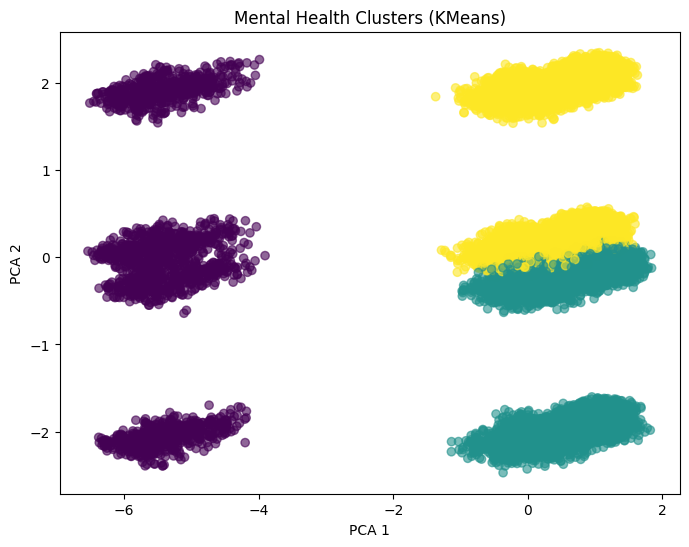

In [ ]:
# ============================================
# 4️⃣ Visualize Clusters (optional PCA)
# ============================================
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='viridis', alpha=0.6)
plt.title("Mental Health Clusters (KMeans)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [ ]:
# ============================================
# 5️⃣ Manually Label Clusters
# ============================================
# ⚠️ Adjust labels based on your cluster_summary results
manual_labels = {
    0: "Healthy",
    1: "Anxiety",
    2: "Depression"
}

df['Mental_Health_Status'] = df['Cluster'].map(manual_labels)

# ============================================

In [ ]:
# ============================================
# 6️⃣ Save or Inspect Results
# ============================================
print("\n🧠 Cluster Label Distribution:")
print(df['Mental_Health_Status'].value_counts())

df.to_csv("mental_health_clustered_labeled.csv", index=False)
print("\n✅ Labeled results saved as 'mental_health_clustered_labeled.csv'")



🧠 Cluster Label Distribution:
Mental_Health_Status
Anxiety       9145
Depression    8858
Healthy       2001
Name: count, dtype: int64

✅ Labeled results saved as 'mental_health_clustered_labeled.csv'


Train Random Forest Classifier

In [ ]:
# ===========================================
# 🧠 Mental Health Detection (Random Forest)
# ===========================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==============================
# 1️⃣ Load the labeled dataset
# ==============================
df = pd.read_csv("mental_health_clustered_labeled.csv")

# Ensure target column exists
if 'Mental_Health_Status' not in df.columns:
    raise ValueError("❌ 'Mental_Health_Status' column not found! Please use the labeled dataset.")

# Drop unnecessary columns
df = df.drop(columns=['User_ID', 'Cluster'], errors='ignore')

# ==============================
# 2️⃣ Encode categorical columns
# ==============================
le_dict = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# ==============================
# 3️⃣ Split features and target
# ==============================
X = df.drop(columns=['Mental_Health_Status'])
y = df['Mental_Health_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# 4️⃣ Train Random Forest
# ==============================
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

# ==============================
# 5️⃣ Evaluate model
# ==============================
y_pred = rf_model.predict(X_test)
print("\n✅ Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ==============================
# 6️⃣ Interactive User Prediction
# ==============================

print("\n🧍‍♂️ Let's check your mental health status prediction!")

def get_user_input():
    user_data = {}
    for col in X.columns:
        if col in le_dict:  # categorical column
            classes = list(le_dict[col].classes_)
            print(f"\nChoose {col} from: {classes}")
            val = input("Enter your choice exactly as shown: ")
            while val not in classes:
                val = input(f"Invalid input! Please choose from {classes}: ")
            user_data[col] = le_dict[col].transform([val])[0]
        else:  # numeric column
            val = float(input(f"Enter value for {col}: "))
            user_data[col] = val
    return pd.DataFrame([user_data])

# Get user input
user_df = get_user_input()

# Predict mental health status
prediction = rf_model.predict(user_df)[0]
status_label = le_dict['Mental_Health_Status'].inverse_transform([prediction])[0]

print("\n🧩 Based on your responses, your predicted mental health status is:")
print(f"👉 {status_label.upper()}")



✅ Model Evaluation:
Accuracy: 0.9980004998750313

Confusion Matrix:
 [[1827    0    2]
 [   0 1772    0]
 [   3    3  394]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1829
           1       1.00      1.00      1.00      1772
           2       0.99      0.98      0.99       400

    accuracy                           1.00      4001
   macro avg       1.00      0.99      1.00      4001
weighted avg       1.00      1.00      1.00      4001


🧍‍♂️ Let's check your mental health status prediction!
Enter value for Age: 21

Choose Gender from: ['Female', 'Male', 'Non-binary', 'Prefer not to say']
Enter your choice exactly as shown: Male

Choose Occupation from: ['Education', 'Engineering', 'Finance', 'Healthcare', 'IT', 'Other', 'Sales']
Enter your choice exactly as shown: Education

Choose Country from: ['Australia', 'Canada', 'Germany', 'India', 'Other', 'UK', 'USA']
Enter your choice exactly as shown: 

In [ ]:
'''import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib  # for saving model
from sklearn.preprocessing import LabelEncoder

# ===========================================================
# 1️⃣ Load the Labeled Data
# ===========================================================
df = pd.read_csv("mental_health_clustered_labeled.csv")

# Drop unnecessary columns
df = df.drop(columns=['Cluster'], errors='ignore')  # if still present
df = df.drop(columns=['User_ID'], errors='ignore')

# Separate features (X) and target (y)
X = df.drop(columns=['Mental_Health_Status'])
y = df['Mental_Health_Status']'''
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans
import numpy as np

# ---------------------------------------------------------
# 1️⃣ Load Dataset
# ---------------------------------------------------------
df = pd.read_csv("mental_health_data final data.csv")

# Drop irrelevant or ID column
df = df.drop(columns=['User_ID'], errors='ignore')


In [ ]:
"""# 2️⃣ Split into Train/Test Sets
# ===========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
"""

# ---------------------------------------------------------
# 2️⃣ Handle Missing Values
# ---------------------------------------------------------
df.fillna(df.mode().iloc[0], inplace=True)

# ---------------------------------------------------------
# 3️⃣ Encode Categorical Columns
# ---------------------------------------------------------
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le


In [ ]:

"""# ===========================================================
# 3️⃣ Train Random Forest Classifier
# ===========================================================
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)"""

# ---------------------------------------------------------
# 4️⃣ Create Clusters Manually (Healthy / Anxiety / Depression)
# ---------------------------------------------------------
# Using KMeans clustering to separate 3 groups
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df)

# Map cluster labels manually
# (You can inspect cluster centers to decide proper mapping if needed)
df['Mental_Health_Status'] = df['Cluster'].map({
    0: 'Healthy',
    1: 'Anxiety',
    2: 'Depression'
})


ValueError: could not convert string to float: 'Male'

In [ ]:
"""
# ===========================================================
# 4️⃣ Evaluate the Model
# ===========================================================
y_pred = rf_model.predict(X_test)

print("\n📊 Model Evaluation:")
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
"""

# ---------------------------------------------------------
# 5️⃣ Prepare Data for Random Forest
# ---------------------------------------------------------
X = df.drop(columns=['Cluster', 'Mental_Health_Status'])
y = df['Mental_Health_Status']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------------------------------------
# 6️⃣ Train Random Forest Model
# ---------------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

AttributeError: 'RandomForestClassifier' object has no attribute 'estimators_'

In [ ]:

# ===========================================================
# 5️⃣ Save the Trained Model
# ===========================================================
joblib.dump(rf_model, "mental_health_rf_model.pkl")
print("\n✅ Model saved as 'mental_health_rf_model.pkl'")

# ===========================================================
# 6️⃣ (Optional) Predict a New User
# ===========================================================
# Example: Replace these values with user inputs or real-time data
sample = X.iloc[0:1]  # using one example row for now
prediction = rf_model.predict(sample)
print("\n🧠 Example Prediction for Sample User:", prediction[0])

In [ ]:
# ===========================================
# 🧠 Mental Health Detection (Random Forest)
# ===========================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==============================
# 1️⃣ Load the labeled dataset
# ==============================
df = pd.read_csv("mental_health_clustered_labeled.csv")

# Ensure target column exists
if 'Mental_Health_Status' not in df.columns:
    raise ValueError("❌ 'Mental_Health_Status' column not found! Please use the labeled dataset.")

# Drop unnecessary columns
df = df.drop(columns=['User_ID', 'Cluster'], errors='ignore')

# ==============================
# 2️⃣ Encode categorical columns
# ==============================
le_dict = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# ==============================
# 3️⃣ Split features and target
# ==============================
X = df.drop(columns=['Mental_Health_Status'])
y = df['Mental_Health_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# 4️⃣ Train Random Forest
# ==============================
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

# ==============================
# 5️⃣ Evaluate model
# ==============================
y_pred = rf_model.predict(X_test)
print("\n✅ Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ==============================
# 6️⃣ Interactive User Prediction
# ==============================

print("\n🧍‍♂️ Let's check your mental health status prediction!")

def get_user_input():
    user_data = {}
    for col in X.columns:
        if col in le_dict:  # categorical column
            classes = list(le_dict[col].classes_)
            print(f"\nChoose {col} from: {classes}")
            val = input("Enter your choice exactly as shown: ")
            while val not in classes:
                val = input(f"Invalid input! Please choose from {classes}: ")
            user_data[col] = le_dict[col].transform([val])[0]
        else:  # numeric column
            val = float(input(f"Enter value for {col}: "))
            user_data[col] = val
    return pd.DataFrame([user_data])

# Get user input
user_df = get_user_input()

# Predict mental health status
prediction = rf_model.predict(user_df)[0]
status_label = le_dict['Mental_Health_Status'].inverse_transform([prediction])[0]

print("\n🧩 Based on your responses, your predicted mental health status is:")
print(f"👉 {status_label.upper()}")



✅ Model Evaluation:
Accuracy: 0.9755061234691327

Confusion Matrix:
 [[1503   23   12]
 [  29 1506   14]
 [  10   10  894]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      1538
           1       0.98      0.97      0.98      1549
           2       0.97      0.98      0.97       914

    accuracy                           0.98      4001
   macro avg       0.98      0.98      0.98      4001
weighted avg       0.98      0.98      0.98      4001


🧍‍♂️ Let's check your mental health status prediction!
Enter value for Age: 21

Choose Gender from: ['Female', 'Male', 'Non-binary', 'Prefer not to say']
Enter your choice exactly as shown: Male

Choose Occupation from: ['Education', 'Engineering', 'Finance', 'Healthcare', 'IT', 'Other', 'Sales']
Enter your choice exactly as shown: Education

Choose Country from: ['Australia', 'Canada', 'Germany', 'India', 'Other', 'UK', 'USA']
Enter your choice exactly as shown: 